In [19]:
import pandas as pd
import numpy as np
import matplotlib as plt



In [20]:
machine= pd.read_csv("/content/machines.csv")
op=pd.read_csv("/content/daily_operations.csv")
trans=pd.read_csv("/content/transactions.csv")

### Machines

In [21]:
machine.head()

,machine_id,location_type,zone,nominal_capacity_items,installation_date,service_window
0,RVM001,Mall,Cairo East,2600,2026-05-12,08:00-22:00
1,RVM002,University,Cairo East,2400,2026-04-20,08:00-22:00
2,RVM003,Corporate Campus,New Cairo,2200,2026-06-01,08:00-22:00
3,RVM004,Sports Club,Maadi,2000,2026-04-05,08:00-22:00
4,RVM005,Hypermarket,Giza,2800,2026-05-25,08:00-22:00


In [22]:
machine.shape

(14, 6)

In [23]:
machine.dtypes

,0
machine_id,object
location_type,object
zone,object
nominal_capacity_items,int64
installation_date,object
service_window,object


In [24]:
machine.isnull().sum()

,0
machine_id,0
location_type,0
zone,0
nominal_capacity_items,0
installation_date,0
service_window,0


In [25]:
machine.duplicated().sum()

np.int64(0)

In [26]:
machine.describe(include='all')

,machine_id,location_type,zone,nominal_capacity_items,installation_date,service_window
count,14,14,14,14.000000,14,14
unique,14,9,7,NaN,14,3
top,RVM001,University,Cairo East,NaN,2026-05-12,08:00-22:00
freq,1,3,3,NaN,1,12
mean,NaN,NaN,NaN,2314.285714,NaN,NaN
std,NaN,NaN,NaN,397.796126,NaN,NaN
min,NaN,NaN,NaN,1800.000000,NaN,NaN
25%,NaN,NaN,NaN,2000.000000,NaN,NaN
50%,NaN,NaN,NaN,2300.000000,NaN,NaN
75%,NaN,NaN,NaN,2550.000000,NaN,NaN


In [27]:
print(machine['location_type'].value_counts())

location_type
University          3
Mall                2
Corporate Campus    2
Sports Club         2
Hypermarket         1
Transit Hub         1
Retail Store        1
Hotel               1
Community Center    1
Name: count, dtype: int64


In [28]:
print(machine['zone'].value_counts())

zone
Cairo East       3
New Cairo        3
Giza             3
Cairo Central    2
Maadi            1
Smart Village    1
Heliopolis       1
Name: count, dtype: int64


In [29]:
print(machine['service_window'].value_counts())

service_window
08:00-22:00    12
06:00-23:00     1
24h             1
Name: count, dtype: int64


In [30]:
machine['installation_date'] = pd.to_datetime(machine['installation_date'])
machine[['machine_id','installation_date']].sort_values('installation_date')

,machine_id,installation_date
3,RVM004,2026-04-05
1,RVM002,2026-04-20
7,RVM008,2026-04-28
5,RVM006,2026-05-05
0,RVM001,2026-05-12
6,RVM007,2026-05-15
8,RVM009,2026-05-18
4,RVM005,2026-05-25
12,RVM013,2026-05-30
2,RVM003,2026-06-01


### Opertions

In [31]:
op.head()

,date,machine_id,opening_fill_pct,accepted_items,rejected_items,pet_items,aluminium_items,pet_weight_kg,aluminium_weight_kg,sessions,unique_users,uptime_pct,fault_minutes,closing_fill_pct,collection_performed_today,needs_collection_next_period,next_period_route_stop,next_period_open_fill_pct
0,2026-07-03,RVM009,32.2,241,7,213,28,2.72,0.45,27,23,96.67,28.0,43.1,0,0,0,43.9
1,2026-07-25,RVM007,36.6,146,5,127,19,1.57,0.30,18,13,95.83,35.0,42.7,0,0,0,43.9
2,2026-08-03,RVM011,20.6,189,8,158,31,1.86,0.45,20,13,97.02,25.0,31.1,0,0,0,31.0
3,2026-08-26,RVM009,5.1,309,12,277,32,3.25,0.45,45,29,99.88,1.0,19.2,1,0,0,19.6
4,2026-09-01,RVM007,65.1,416,18,368,48,5.36,0.71,58,36,97.50,21.0,82.4,0,1,1,10.3


In [32]:
op.shape

(1049, 18)

In [33]:
op.dtypes

,0
date,object
machine_id,object
opening_fill_pct,float64
accepted_items,int64
rejected_items,int64
pet_items,int64
aluminium_items,int64
pet_weight_kg,float64
aluminium_weight_kg,float64
sessions,int64


In [34]:
op.isnull().sum()

,0
date,0
machine_id,0
opening_fill_pct,0
accepted_items,0
rejected_items,0
pet_items,0
aluminium_items,0
pet_weight_kg,0
aluminium_weight_kg,0
sessions,0


In [35]:
op[op['uptime_pct'].isnull() | op['fault_minutes'].isnull() | op['closing_fill_pct'].isnull()]

,date,machine_id,opening_fill_pct,accepted_items,rejected_items,pet_items,aluminium_items,pet_weight_kg,aluminium_weight_kg,sessions,unique_users,uptime_pct,fault_minutes,closing_fill_pct,collection_performed_today,needs_collection_next_period,next_period_route_stop,next_period_open_fill_pct
95,2026-08-06,RVM013,81.2,130,3,112,18,1.55,0.22,15,12,97.50,36.0,NaN,0,1,1,10.0
118,2026-07-14,RVM003,46.5,205,7,179,26,2.31,0.38,26,19,99.76,2.0,NaN,0,0,0,57.3
135,2026-07-20,RVM003,16.2,238,11,201,37,2.60,0.53,26,19,92.74,NaN,27.0,0,0,0,26.6
160,2026-07-18,RVM006,19.1,516,16,463,53,5.87,0.88,63,43,NaN,1.0,35.2,0,0,0,36.4
302,2026-08-25,RVM013,63.8,129,3,109,20,1.39,0.33,13,10,97.57,NaN,70.9,0,0,0,69.7
410,2026-07-29,RVM010,65.1,244,7,204,40,2.53,0.59,25,21,99.64,NaN,77.3,0,0,1,10.8
417,2026-08-05,RVM007,63.1,377,15,291,86,3.84,1.37,44,36,NaN,16.0,78.8,0,0,0,77.9
561,2026-08-09,RVM013,23.8,135,6,113,22,1.43,0.38,13,9,98.75,18.0,NaN,0,0,0,31.3
637,2026-09-12,RVM012,74.3,262,11,241,21,3.13,0.33,28,22,NaN,0.0,85.2,0,1,1,7.8
665,2026-07-23,RVM006,100.6,110,34,4,106,9.03,1.59,106,88,99.80,2.0,NaN,0,1,1,7.5


In [36]:
op.isnull().sum()

,0
date,0
machine_id,0
opening_fill_pct,0
accepted_items,0
rejected_items,0
pet_items,0
aluminium_items,0
pet_weight_kg,0
aluminium_weight_kg,0
sessions,0


In [37]:
op = op.dropna(subset=['fault_minutes'])

In [38]:
op.isnull().sum()

,0
date,0
machine_id,0
opening_fill_pct,0
accepted_items,0
rejected_items,0
pet_items,0
aluminium_items,0
pet_weight_kg,0
aluminium_weight_kg,0
sessions,0


In [39]:

op = op.dropna(subset=['closing_fill_pct'])

In [40]:
op.isnull().sum()

,0
date,0
machine_id,0
opening_fill_pct,0
accepted_items,0
rejected_items,0
pet_items,0
aluminium_items,0
pet_weight_kg,0
aluminium_weight_kg,0
sessions,0


In [41]:
op.duplicated().sum()

np.int64(5)

In [42]:
print(op.duplicated(subset=['machine_id','date']).sum())


5


In [43]:
dupes = op[op.duplicated(subset=['machine_id','date'], keep=False)].sort_values(['machine_id','date'])
print(dupes)

           date machine_id  opening_fill_pct  accepted_items  rejected_items  \
387  2026-07-13     RVM003              36.8             214               9   
926  2026-07-13     RVM003              36.8             214               9   
350  2026-07-22     RVM005              30.2             395              15   
502  2026-07-22     RVM005              30.2             395              15   
528  2026-08-06     RVM005              49.3             307              11   
902  2026-08-06     RVM005              49.3             307              11   
842  2026-08-07     RVM006               4.5             761              27   
901  2026-08-07     RVM006               4.5             761              27   
373  2026-08-06     RVM010              19.1             243               7   
393  2026-08-06     RVM010              19.1             243               7   

     pet_items  aluminium_items  pet_weight_kg  aluminium_weight_kg  sessions  \
387        182               32       

In [44]:
op = op.drop_duplicates(subset=['machine_id','date'], keep='first').reset_index(drop=True)

In [45]:
op.describe(include='all')

,date,machine_id,opening_fill_pct,accepted_items,rejected_items,pet_items,aluminium_items,pet_weight_kg,aluminium_weight_kg,sessions,unique_users,uptime_pct,fault_minutes,closing_fill_pct,collection_performed_today,needs_collection_next_period,next_period_route_stop,next_period_open_fill_pct
count,1027,1027,1027.000000,1027.000000,1027.000000,1027.000000,1027.000000,1027.000000,1027.000000,1027.000000,1027.000000,1019.000000,1027.000000,1027.000000,1027.000000,1027.000000,1027.000000,1027.000000
unique,77,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,2026-09-01,RVM007,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,14,77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,41.412756,304.850049,11.308666,259.889971,45.008763,3.465200,0.675316,38.875365,28.616358,97.362414,23.185005,54.386271,0.156767,0.168452,0.184031,40.659007
std,NaN,NaN,24.115698,139.803841,6.344800,119.362719,22.552839,1.916038,0.341134,19.131484,14.586598,2.939315,26.778909,24.331410,0.363758,0.374449,0.387698,24.274401
min,NaN,NaN,3.000000,0.000000,1.000000,0.000000,7.000000,0.700000,0.100000,8.000000,5.000000,82.000000,-20.000000,-6.000000,0.000000,0.000000,0.000000,3.100000
25%,NaN,NaN,20.650000,207.000000,7.000000,176.000000,29.000000,2.280000,0.430000,25.000000,18.000000,96.495000,6.000000,34.000000,0.000000,0.000000,0.000000,19.600000
50%,NaN,NaN,40.300000,287.000000,10.000000,246.000000,42.000000,3.250000,0.640000,36.000000,26.000000,98.210000,15.000000,53.700000,0.000000,0.000000,0.000000,40.100000
75%,NaN,NaN,61.200000,379.000000,14.000000,323.000000,57.000000,4.220000,0.860000,49.000000,36.000000,99.290000,31.000000,74.800000,0.000000,0.000000,0.000000,60.600000


In [46]:
op[op['uptime_pct'] > 100]

,date,machine_id,opening_fill_pct,accepted_items,rejected_items,pet_items,aluminium_items,pet_weight_kg,aluminium_weight_kg,sessions,unique_users,uptime_pct,fault_minutes,closing_fill_pct,collection_performed_today,needs_collection_next_period,next_period_route_stop,next_period_open_fill_pct
621,2026-07-08,RVM008,15.9,335,12,281,54,3.29,0.83,37,32,103.5,3.0,28.7,0,0,0,27.5


In [47]:
op.loc[op['uptime_pct'] > 100, 'uptime_pct'] = 100

In [48]:
(op['uptime_pct'] == 82.00).sum()
op[op['uptime_pct']==82.00]['machine_id'].value_counts()

,count
machine_id,
RVM008,7
RVM010,1


In [49]:
op.groupby('machine_id')['fault_minutes'].mean().sort_values(ascending=False)

,fault_minutes
machine_id,
RVM008,50.558442
RVM001,23.760000
RVM010,23.092105
RVM004,22.378378
RVM003,22.240000
RVM011,22.077922
RVM007,21.831169
RVM009,21.763158
RVM014,20.840000


<Axes: title={'center': 'Average Fault Minutes by Machine'}, xlabel='machine_id', ylabel='Minutes'>

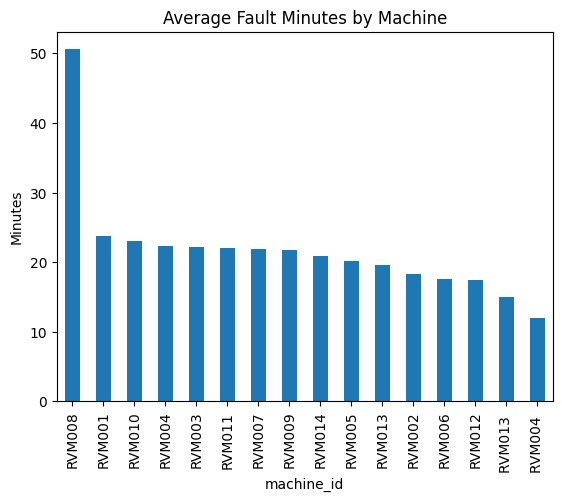

In [50]:
op.groupby('machine_id')['fault_minutes'].mean().sort_values(ascending=False).plot(
    kind='bar', title='Average Fault Minutes by Machine', ylabel='Minutes'
)

In [51]:
op[['machine_id','date','sessions','unique_users','accepted_items']].sample(15)

,machine_id,date,sessions,unique_users,accepted_items
875,RVM004,2026-08-14,30,19,216
697,RVM011,2026-07-03,30,24,246
622,RVM014,2026-09-09,22,14,176
980,RVM001,2026-09-04,38,29,351
649,RVM011,2026-09-04,25,17,181
111,RVM003,2026-09-07,36,29,325
715,RVM008,2026-08-08,61,42,441
742,RVM001,2026-08-06,38,24,274
116,RVM006,2026-07-04,57,45,468
405,RVM001,2026-07-02,27,17,232


In [52]:
df = op.merge(machine, on='machine_id', how='left')
df.groupby('location_type')[['accepted_items','rejected_items']].sum()

,accepted_items,rejected_items
location_type,,
Community Center,15622,560
Corporate Campus,34196,1181
Hotel,9335,307
Hypermarket,28121,1055
Mall,54396,2346
Retail Store,15005,526
Sports Club,43341,1556
Transit Hub,40407,1477
University,72196,2587


<Axes: title={'center': 'Total accepted items over time'}, xlabel='date'>

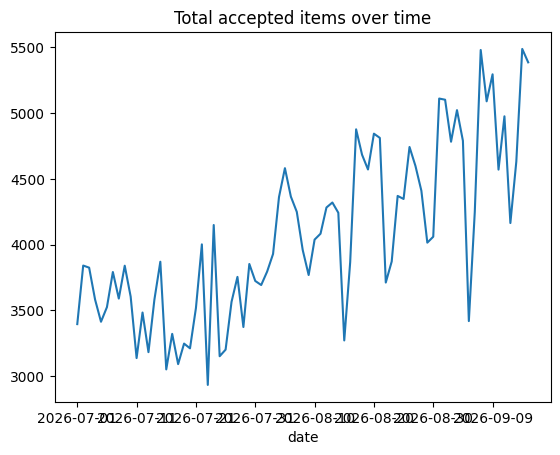

In [53]:
op.groupby('date')['accepted_items'].sum().plot(title='Total accepted items over time')

In [54]:
cols = ['accepted_items','rejected_items','uptime_pct','fault_minutes','opening_fill_pct']
op[cols].corr()

,accepted_items,rejected_items,uptime_pct,fault_minutes,opening_fill_pct
accepted_items,1.000000,0.841827,0.003543,-0.015499,-0.095478
rejected_items,0.841827,1.000000,-0.183509,0.182707,-0.058429
uptime_pct,0.003543,-0.183509,1.000000,-0.980181,-0.011489
fault_minutes,-0.015499,0.182707,-0.980181,1.000000,0.017518
opening_fill_pct,-0.095478,-0.058429,-0.011489,0.017518,1.000000


In [55]:
op[['machine_id','date','sessions','unique_users','accepted_items']].sample(15)

,machine_id,date,sessions,unique_users,accepted_items
524,RVM004,2026-07-27,36,25,309
213,RVM002,2026-08-17,91,58,634
827,RVM009,2026-08-31,40,29,338
11,RVM013,2026-08-21,18,12,126
500,RVM004,2026-08-15,34,24,342
305,RVM011,2026-08-23,12,7,119
147,RVM013,2026-07-16,14,10,112
828,RVM014,2026-07-06,23,15,189
541,RVM013,2026-07-14,15,10,117
285,RVM014,2026-07-18,21,16,157


In [56]:
daily_ids = set(op['machine_id'].unique())
machine_ids = set(machine['machine_id'].unique())
print("In daily but not machines:", daily_ids - machine_ids)
print("In machines but not daily:", machine_ids - daily_ids)

In daily but not machines: {'RVM004 ', 'RVM013 '}
In machines but not daily: set()


In [57]:
op['machine_id'] = op['machine_id'].str.strip()
machine['machine_id'] = machine['machine_id'].str.strip()

### Transactions

In [58]:
trans.head()

,transaction_id,timestamp,machine_id,anonymised_user_id,material_type,accepted_status,items_count,reward_points
0,T0005730,2026-07-14 19:26:37,RVM006,U04051,PET,accepted,8,16
1,T0005649,2026-07-14 08:59:23,RVM004,U01201,PET,accepted,1,2
2,T0016220,2026-08-06 21:04:23,RVM012,U02959,AL,accepted,9,36
3,T0008674,2026-07-21 15:18:23,RVM009,U03858,PET,accepted,21,42
4,T0034878,2026-09-10 15:23:46,RVM007,U02248,AL,rejected,2,0


In [59]:
trans.shape

(38086, 8)

In [60]:
trans.dtypes

,0
transaction_id,object
timestamp,object
machine_id,object
anonymised_user_id,object
material_type,object
accepted_status,object
items_count,int64
reward_points,int64


In [61]:
trans.isnull().sum()

,0
transaction_id,0
timestamp,0
machine_id,0
anonymised_user_id,317
material_type,0
accepted_status,0
items_count,0
reward_points,0


In [62]:
print(trans.duplicated().sum())
print(trans.duplicated(subset=['transaction_id']).sum())

10
10


In [63]:
trans[trans.duplicated(subset=['transaction_id'], keep=False)].sort_values('transaction_id')

,transaction_id,timestamp,machine_id,anonymised_user_id,material_type,accepted_status,items_count,reward_points
9740,T0001066,2026-07-03 11:57:13,RVM006,U04042,AL,accepted,20,80
30098,T0001066,2026-07-03 11:57:13,RVM006,U04042,AL,accepted,20,80
34973,T0005623,2026-07-14 19:09:24,RVM002,U02736,Unknown,rejected,5,0
22310,T0005623,2026-07-14 19:09:24,RVM002,U02736,Unknown,rejected,5,0
35314,T0008101,2026-07-20 14:09:49,RVM005,U00130,PET,accepted,9,18
19685,T0008101,2026-07-20 14:09:49,RVM005,U00130,PET,accepted,9,18
7060,T0009281,2026-07-23 20:16:20,RVM001,U03712,PET,accepted,10,20
27347,T0009281,2026-07-23 20:16:20,RVM001,U03712,PET,accepted,10,20
20210,T0016022,2026-08-06 08:54:54,RVM007,U02581,PET,accepted,17,34
17833,T0016022,2026-08-06 08:54:54,RVM007,U02581,PET,accepted,17,34


In [64]:
trans = trans.drop_duplicates(subset=['transaction_id'], keep='first').reset_index(drop=True)


In [65]:

trans[trans['anonymised_user_id'].notnull()]['reward_points'].describe()

,reward_points
count,37759.000000
mean,19.391403
std,14.817046
min,-126.000000
25%,10.000000
50%,18.000000
75%,26.000000
max,180.000000


In [66]:
trans[trans['anonymised_user_id'].isnull()]['reward_points'].describe()

,reward_points
count,317.000000
mean,19.160883
std,13.437713
min,0.000000
25%,10.000000
50%,18.000000
75%,28.000000
max,68.000000


In [67]:
trans['user_id_missing'] = trans['anonymised_user_id'].isnull()

In [68]:
print(trans['material_type'].value_counts())

material_type
PET        29147
AL          7173
Unknown     1756
Name: count, dtype: int64


In [69]:
print(trans['accepted_status'].value_counts())

accepted_status
accepted    32697
rejected     5379
Name: count, dtype: int64


In [70]:
pd.crosstab(trans['material_type'], trans['accepted_status'], normalize='index')

accepted_status,accepted,rejected
material_type,,
AL,0.749617,0.250383
PET,0.937318,0.062682
Unknown,0.000000,1.000000


In [71]:
known_users = trans[trans['anonymised_user_id'].notnull()]
user_counts = known_users.groupby('anonymised_user_id').size()
user_counts.describe()

,0
count,4200.000000
mean,8.990238
std,3.025831
min,1.000000
25%,7.000000
50%,9.000000
75%,11.000000
max,23.000000


### Part 2

In [72]:
op = op.sort_values(['machine_id','date']).reset_index(drop=True)



In [73]:
def days_since_last_collection(group):
    counter = []
    days_since = 0
    for val in group['collection_performed_today']:
        if val == 1:
            days_since = 0
        else:
            days_since += 1
        counter.append(days_since)
    group['days_since_collection'] = counter
    return group

In [74]:
op = op.groupby('machine_id', group_keys=False).apply(days_since_last_collection)

/tmp/ipykernel_36528/2300728491.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  op = op.groupby('machine_id', group_keys=False).apply(days_since_last_collection)


In [75]:
op[['machine_id','date','collection_performed_today','days_since_collection']].head(20)

,machine_id,date,collection_performed_today,days_since_collection
0,RVM001,2026-07-01,0,1
1,RVM001,2026-07-02,0,2
2,RVM001,2026-07-03,0,3
3,RVM001,2026-07-04,0,4
4,RVM001,2026-07-05,0,5
5,RVM001,2026-07-06,1,0
6,RVM001,2026-07-07,0,1
7,RVM001,2026-07-08,0,2
8,RVM001,2026-07-09,0,3
9,RVM001,2026-07-10,0,4


In [76]:
op['fill_gained_today'] = op['closing_fill_pct'] - op['opening_fill_pct']

In [77]:
md = op.merge(machine, on='machine_id', how='left')


In [78]:
md['date'] = pd.to_datetime(md['date'])

In [79]:
md['days_since_install'] = (md['date'] - md['installation_date']).dt.days


In [80]:
md['rejection_rate'] = md['rejected_items'] / (md['accepted_items'] + md['rejected_items'])

In [81]:
md.head()

,date,machine_id,opening_fill_pct,accepted_items,rejected_items,pet_items,aluminium_items,pet_weight_kg,aluminium_weight_kg,sessions,...,next_period_open_fill_pct,days_since_collection,fill_gained_today,location_type,zone,nominal_capacity_items,installation_date,service_window,days_since_install,rejection_rate
0,2026-07-01,RVM001,25.4,411,15,346,65,4.34,0.91,56,...,42.3,1,15.8,Mall,Cairo East,2600,2026-05-12,08:00-22:00,50,0.035211
1,2026-07-02,RVM001,41.2,232,9,197,35,2.85,0.61,27,...,49.8,2,8.9,Mall,Cairo East,2600,2026-05-12,08:00-22:00,51,0.037344
2,2026-07-03,RVM001,50.1,244,7,204,40,2.88,0.64,29,...,59.5,3,9.4,Mall,Cairo East,2600,2026-05-12,08:00-22:00,52,0.027888
3,2026-07-04,RVM001,59.5,371,14,333,38,4.70,0.55,49,...,73.9,4,14.3,Mall,Cairo East,2600,2026-05-12,08:00-22:00,53,0.036364
4,2026-07-05,RVM001,73.8,390,13,323,67,4.07,1.00,53,...,5.4,5,15.0,Mall,Cairo East,2600,2026-05-12,08:00-22:00,54,0.032258


In [82]:
md.groupby('needs_collection_next_period')[['closing_fill_pct','days_since_collection']].describe()

closing_fill_pct                              \
                                        count       mean        std   min   
needs_collection_next_period                                                
0                                       854.0  47.844848  20.242793  -6.0   
1                                       173.0  86.677457  15.428391  18.2   

                                                            \
                                 25%    50%     75%    max   
needs_collection_next_period                                 
0                             30.925  47.05  63.875  118.0   
1                             84.300  88.80  93.600  132.0   

                             days_since_collection                           \
                                             count      mean       std  min   
needs_collection_next_period                                                  
0                                            854.0  2.453162  2.033606  0.0   
1                                            173.0  5.167630  2.068786  0.0   

                                                   
                              25%  50%  75%   max  
needs_collection_next_period                       
0                             1.0  2.0  4.0  11.0  
1                             4.0  5.0  6.0  13.0

In [83]:
md.groupby('needs_collection_next_period')[['closing_fill_pct','days_since_collection']].describe()

closing_fill_pct                              \
                                        count       mean        std   min   
needs_collection_next_period                                                
0                                       854.0  47.844848  20.242793  -6.0   
1                                       173.0  86.677457  15.428391  18.2   

                                                            \
                                 25%    50%     75%    max   
needs_collection_next_period                                 
0                             30.925  47.05  63.875  118.0   
1                             84.300  88.80  93.600  132.0   

                             days_since_collection                           \
                                             count      mean       std  min   
needs_collection_next_period                                                  
0                                            854.0  2.453162  2.033606  0.0   
1                                            173.0  5.167630  2.068786  0.0   

                                                   
                              25%  50%  75%   max  
needs_collection_next_period                       
0                             1.0  2.0  4.0  11.0  
1                             4.0  5.0  6.0  13.0

In [84]:
md['baseline_pred'] = (
    (md['closing_fill_pct'] > 80) | (md['days_since_collection'] > 5)
).astype(int)

In [85]:
from sklearn.metrics import classification_report
print(classification_report(md['needs_collection_next_period'], md['baseline_pred']))

              precision    recall  f1-score   support

           0       0.97      0.89      0.93       854
           1       0.61      0.87      0.72       173

    accuracy                           0.89      1027
   macro avg       0.79      0.88      0.82      1027
weighted avg       0.91      0.89      0.89      1027



In [86]:
md = md.sort_values('date')
cutoff = md['date'].quantile(0.75)
train = md[md['date'] <= cutoff]
test = md[md['date'] > cutoff]
print(train.shape, test.shape)
print("Train date range:", train['date'].min(), "to", train['date'].max())
print("Test date range:", test['date'].min(), "to", test['date'].max())

(775, 28) (252, 28)
Train date range: 2026-07-01 00:00:00 to 2026-08-28 00:00:00
Test date range: 2026-08-29 00:00:00 to 2026-09-15 00:00:00


In [87]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, fbeta_score, confusion_matrix



In [88]:
features = ['closing_fill_pct','opening_fill_pct','fill_gained_today','days_since_collection',
            'uptime_pct','fault_minutes','rejection_rate','nominal_capacity_items']



In [89]:
X_train = train[features].fillna(train[features].median())
y_train = train['needs_collection_next_period']
X_test = test[features].fillna(train[features].median())
y_test = test['needs_collection_next_period']



In [90]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


In [91]:
model = LogisticRegression(class_weight='balanced')
model.fit(X_train_s, y_train)

LogisticRegression(class_weight='balanced')

In [92]:
y_pred = model.predict(X_test_s)


In [93]:
print(classification_report(y_test, y_pred))
print("Model F2:", fbeta_score(y_test, y_pred, beta=2))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.86      0.92       205
           1       0.61      0.94      0.74        47

    accuracy                           0.88       252
   macro avg       0.80      0.90      0.83       252
weighted avg       0.91      0.88      0.89       252

Model F2: 0.8461538461538461
[[177  28]
 [  3  44]]


In [94]:
import pandas as pd
coef_df = pd.DataFrame({'feature': features, 'coefficient': model.coef_[0]}).sort_values('coefficient', ascending=False)
print(coef_df)

                  feature  coefficient
0        closing_fill_pct     1.396183
1        opening_fill_pct     1.361221
5           fault_minutes     0.474765
4              uptime_pct     0.312503
2       fill_gained_today     0.248526
7  nominal_capacity_items    -0.027737
6          rejection_rate    -0.175933
3   days_since_collection    -0.372906


In [95]:
md[['opening_fill_pct','closing_fill_pct','days_since_collection']].corr()

,opening_fill_pct,closing_fill_pct,days_since_collection
opening_fill_pct,1.000000,0.974418,0.876273
closing_fill_pct,0.974418,1.000000,0.822200
days_since_collection,0.876273,0.822200,1.000000


# Part 3

### What did you discover?

Before analyzing the results, we had to clean up the data. We found duplicate records, typos in machine IDs, and illogical sensor readings. For instance, some fill levels showed over 100%, and one machine reported exactly 82% uptime in a highly suspicious way.

Once we cleaned things up, a clear picture emerged. Most machines operate normally, but a few specific issues stand out.

### Which machines or situations deserve attention?

**RVM008 demands the most attention.** It experiences more than twice the faults and downtime of any other machine in the fleet.

We also noticed a significant problem with **aluminium cans**. They get rejected roughly four times as often as PET bottles, hitting a 25% rejection rate compared to just 6% for plastics. Since the machines reject anything they cannot easily identify, this could easily frustrate users. It is definitely worth investigating how the cans are shaped, crushed, or scanned to improve detection.

### What seems to drive the need for collection?

The driving factor is incredibly straightforward: **how full the machine is.**

Machines requiring a pickup are usually over 80% full, whereas machines that can wait generally sit below 50% capacity. The time passed since the last collection also plays a role, though mostly because uncollected machines naturally fill up over time.
.

### Does the ML model add enough value compared with the simple rule?

Yes, though the upgrade is practical rather than revolutionary.

Relying on a basic rule to flag a machine at 80% capacity or after five days without collection successfully catches about 87% of the machines needing service. The ML model pushes that success rate to 94%. Practically speaking, it misses only 3 .

The catch is that the model will occasionally suggest unnecessary collections. However, since overflowing machines cost more in customer dissatisfaction than an extra truck stop, catching those  additional cases adds real business value.



### How would you use the model in day-to-day operations?

I would avoid using it for automated truck dispatching. Instead, it works best as a daily priority list.

At the end of the day, the model can assign a risk score to every machine in the network. High-scoring locations get bumped to the top of the queue for the next morning's collection planning. Because overflowing machines cause major headaches, we want a generous threshold. Checking on a machine that happens to be fine is much better than ignoring one until it overflows.

Ultimately, the human route planner retains the final say. The model simply answers "Which machines should we look at first?" instead of forcing a fixed route on the drivers.

### What could go wrong if we trusted the model blindly?

Blind trust comes with a few distinct risks.

* The dataset is relatively small.Training on two and a half months of data from just 14 machines gives us a solid prototype, but it leaves us blind to holiday rushes, seasonal shifts, or entirely new machine types.
* Hardware reliability dictates model accuracy. We already spotted faulty sensor readings in the historical data. If a sensor breaks and nobody notices, the model will confidently make terrible recommendations based on bad inputs.
* The system leans toward caution. We trained it to prioritize catching full machines over minimizing trips. This means it will occasionally send a truck out for no reason. While acceptable in small doses, those extra trips do cost time and fuel.

### What additional data should Drop Me start collecting?

Improving our data collection is the best way to build a more trustworthy and capable system moving forward.

1. **More frequent fill-level readings:** Daily opening and closing stats are insufficient. Timestamped fill readings throughout the day would let us spot rapid usage spikes immediately.
4. **Sensor health diagnostics:** The hardware should ideally flag its own malfunctions. If a fill sensor starts returning erratic numbers, the system needs to recognize the hardware failure instead of assuming the data is real.
5. **Long-term historical tracking:** Two and a half months is just a starting point. A full year of data will reveal how weather, holidays, and seasonal trends impact usage rates, allowing the system to shift from reacting to predicting.

**What would you change in your current approach before trusting it at that scale?**
The first thing I would focus on is getting more reliable and consistent data. With hundreds of machines, there will likely be different machine types, different locations, and different sensor behavior, so a single model trained on a small group of machines may not work equally well everywhere. I would collect more historical data across different seasons and locations, make sure collection events are recorded properly, and add checks that can detect faulty or unusual sensor readings before they reach the model.At a larger scale, the cost of sending a truck, the distance between machines, truck capacity, collection time, and location would all matter